In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 1. Load The Data

In [3]:
data = pd.read_csv('modified_dataset.csv')
data

,age,job,marital,education_qual,call_type,day,mon,dur,num_calls,prev_outcome,y
0,58,management,married,tertiary,unknown,5,NaN,261.0,1,NaN,no
1,44,NaN,single,secondary,unknown,5,NaN,151.0,1,unknown,no
2,33,entrepreneur,married,secondary,unknown,5,may,76.0,1,unknown,no
3,47,blue-collar,married,NaN,unknown,5,NaN,92.0,1,unknown,no
4,33,unknown,single,unknown,unknown,5,may,198.0,1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,NaN,cellular,17,NaN,977.0,3,NaN,yes
45207,71,NaN,divorced,primary,cellular,17,NaN,456.0,2,unknown,yes
45208,72,NaN,married,NaN,cellular,17,NaN,1127.0,5,success,yes
45209,57,blue-collar,married,secondary,telephone,17,NaN,508.0,4,unknown,no


## 2. Rename The Columns For Your Convenience

## 3. Check The Target Imbalance

In [7]:
data['Subscription Status'].value_counts()

Subscription Status
no     39922
yes     5289
Name: count, dtype: int64

### Since The Ratio % Of No And Yes is 88:12, Accuracy Score Is Not Possible

## 4. Data Preprocessing

### A. Check The Data Type

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45211 non-null  int64  
 1   Job                                            33909 non-null  object 
 2   Marital Status                                 45211 non-null  object 
 3   Educational Qualification                      33909 non-null  object 
 4   Contact Communication type                     45211 non-null  object 
 5   Last Contact Day Of The Month                  45211 non-null  int64  
 6   Last Contact Month Of The Year                 33909 non-null  object 
 7   Contact Duration (Seconds)                     33909 non-null  float64
 8   No Of Contacts Performed During This Campaign  45211 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         339

#### We Can See That There Are Null Values Too In This Dataset

### B. Duplicate Removal

In [14]:
len(data.loc[data.duplicated()])

52

In [15]:
data.drop_duplicates(inplace = True)
len(data.loc[data.duplicated()])

0

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            33873 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

### C. Outlier Check

In [18]:
data.describe()

,Age,Last Contact Day Of The Month,Contact Duration (Seconds),No Of Contacts Performed During This Campaign
count,45159.000000,45159.000000,33908.000000,45159.000000
mean,40.940986,15.806196,258.513979,2.765008
std,10.620179,8.323979,258.070115,3.099442
min,18.000000,1.000000,0.000000,1.000000
25%,33.000000,8.000000,103.000000,1.000000
50%,39.000000,16.000000,180.000000,2.000000
75%,48.000000,21.000000,319.000000,3.000000
max,95.000000,31.000000,4918.000000,63.000000


In [19]:
data_Out = data[['Age','Contact Duration (Seconds)','No Of Contacts Performed During This Campaign']]

In [20]:
data_Out

,Age,Contact Duration (Seconds),No Of Contacts Performed During This Campaign
0,58,261.0,1
1,44,151.0,1
2,33,76.0,1
3,47,92.0,1
4,33,198.0,1
...,...,...,...
45206,51,977.0,3
45207,71,456.0,2
45208,72,1127.0,5
45209,57,508.0,4


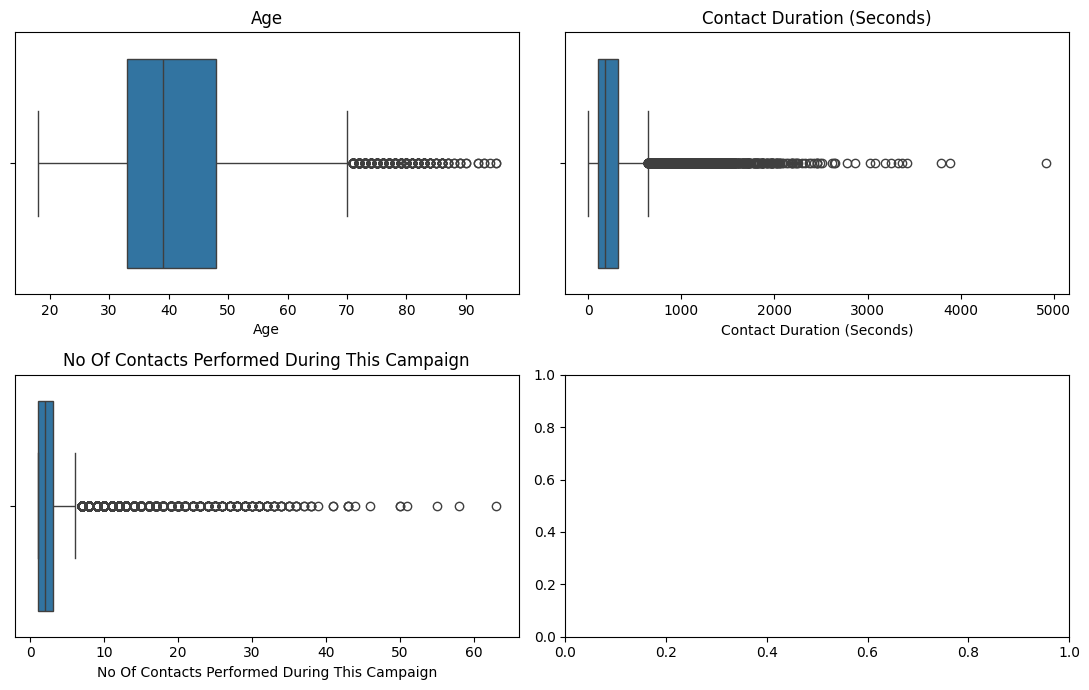

In [21]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize =(11,7))
ax=ax.flatten()

for i,cols in enumerate(data_Out.columns):
    sns.boxplot(x=data_Out[cols],ax=ax[i])
    ax[i].set_title(f'{cols}')
plt.tight_layout()
plt.show()

In [22]:
Age_Limit = len(data_Out.loc[data_Out['Age']>70])
Contact_Duration_Limit = len(data_Out.loc[data_Out['Contact Duration (Seconds)']>640])
Contact_Limit = len(data_Out.loc[data_Out['No Of Contacts Performed During This Campaign']>6])
print(f'The No Of Data Exceeding The Age Limit Is :- {Age_Limit}')

print(f'The No Of Data Exceeding The Contact Duration Limit Is :- {Contact_Duration_Limit}')

print(f'The No Of Data Exceeding The Contact Limit Is :- {Contact_Limit}')

The No Of Data Exceeding The Age Limit Is :- 487
The No Of Data Exceeding The Contact Duration Limit Is :- 2455
The No Of Data Exceeding The Contact Limit Is :- 3064


### D. Unique Check

In [24]:
data_Cat=data.select_dtypes(include = 'object')
data_Cat

,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Month Of The Year,Outcome Of Previous Marketing Campaign,Subscription Status
0,management,married,tertiary,unknown,NaN,NaN,no
1,NaN,single,secondary,unknown,NaN,unknown,no
2,entrepreneur,married,secondary,unknown,may,unknown,no
3,blue-collar,married,NaN,unknown,NaN,unknown,no
4,unknown,single,unknown,unknown,may,unknown,no
...,...,...,...,...,...,...,...
45206,technician,married,NaN,cellular,NaN,NaN,yes
45207,NaN,divorced,primary,cellular,NaN,unknown,yes
45208,NaN,married,NaN,cellular,NaN,success,yes
45209,blue-collar,married,secondary,telephone,NaN,unknown,no


In [25]:
for i in data_Cat.columns:
    print(f'The Unique Values Of {i} Are {[data_Cat[i].unique()]}\n')

The Unique Values Of Job Are [array(['management', nan, 'entrepreneur', 'blue-collar', 'unknown',
       'retired', 'technician', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)]

The Unique Values Of Marital Status Are [array(['married', 'single', 'divorced'], dtype=object)]

The Unique Values Of Educational Qualification Are [array(['tertiary', 'secondary', nan, 'unknown', 'primary'], dtype=object)]

The Unique Values Of Contact Communication type Are [array(['unknown', 'cellular', 'telephone'], dtype=object)]

The Unique Values Of Last Contact Month Of The Year Are [array([nan, 'may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb',
       'mar', 'apr', 'sep'], dtype=object)]

The Unique Values Of Outcome Of Previous Marketing Campaign Are [array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)]

The Unique Values Of Subscription Status Are [array(['no', 'yes'], dtype=object)]



### E. EDA For Null Imputation

In [27]:
data_2 = data.copy()

In [28]:
data_2

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status
0,58,management,married,tertiary,unknown,5,NaN,261.0,1,NaN,no
1,44,NaN,single,secondary,unknown,5,NaN,151.0,1,unknown,no
2,33,entrepreneur,married,secondary,unknown,5,may,76.0,1,unknown,no
3,47,blue-collar,married,NaN,unknown,5,NaN,92.0,1,unknown,no
4,33,unknown,single,unknown,unknown,5,may,198.0,1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,NaN,cellular,17,NaN,977.0,3,NaN,yes
45207,71,NaN,divorced,primary,cellular,17,NaN,456.0,2,unknown,yes
45208,72,NaN,married,NaN,cellular,17,NaN,1127.0,5,success,yes
45209,57,blue-collar,married,secondary,telephone,17,NaN,508.0,4,unknown,no


In [29]:
l1=[]
def cat(age):
    if 0<age<=20:
        return '0-20'
    elif 20<age<=25:
        return '21-25'
    elif 25<age<=30:
        return '26-30'
    elif 30<age<=35:
        return '31-35'
    elif 35<age<=40:
        return '36-40'
    elif 40<age<=45:
        return '41-45'
    elif 45<age<=50:
        return '46-50'
    elif 50<age<=55:
        return '51-55'
    elif 55<age<=60:
        return '56-60'
    elif 60<age<=65:
        return '61-65'
    elif 65<age<=70:
        return '66-70'
    elif 70<age<=75:
        return '71-75'
    elif 75<age<=80:
        return '76-80'
    elif 80<age<=85:
        return '81-85'
    elif 85<age<=90:
        return '86-90'
    elif 90<age<=95:
        return '91-95'
    elif 95<age<=100:
        return '96-100'

In [30]:
data_2['Age_Category'] = data_2['Age'].apply(cat)

In [31]:
data_2

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status,Age_Category
0,58,management,married,tertiary,unknown,5,NaN,261.0,1,NaN,no,56-60
1,44,NaN,single,secondary,unknown,5,NaN,151.0,1,unknown,no,41-45
2,33,entrepreneur,married,secondary,unknown,5,may,76.0,1,unknown,no,31-35
3,47,blue-collar,married,NaN,unknown,5,NaN,92.0,1,unknown,no,46-50
4,33,unknown,single,unknown,unknown,5,may,198.0,1,unknown,no,31-35
...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,NaN,cellular,17,NaN,977.0,3,NaN,yes,51-55
45207,71,NaN,divorced,primary,cellular,17,NaN,456.0,2,unknown,yes,71-75
45208,72,NaN,married,NaN,cellular,17,NaN,1127.0,5,success,yes,71-75
45209,57,blue-collar,married,secondary,telephone,17,NaN,508.0,4,unknown,no,56-60


#### A. Set The Job Null Values To 'Retired' Whose Age Is Between '56-100'

In [33]:
data_2['Age_Category'].value_counts()

Age_Category
31-35    9863
36-40    7799
41-45    6040
26-30    5683
46-50    5190
51-55    4352
56-60    3710
21-25    1237
61-65     437
66-70     264
71-75     226
76-80     162
0-20       97
81-85      72
86-90      20
91-95       7
Name: count, dtype: int64

In [34]:
Job_Retired= data_2.loc[data_2['Job']=='retired']
Job_Retired

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status,Age_Category
8,58,retired,married,primary,unknown,5,may,50.0,1,unknown,no,56-60
15,51,retired,married,primary,unknown,5,NaN,NaN,1,NaN,no,51-55
18,60,retired,married,NaN,unknown,5,may,219.0,1,NaN,no,56-60
89,57,retired,married,secondary,unknown,5,NaN,NaN,2,unknown,no,56-60
97,60,retired,married,tertiary,unknown,5,may,101.0,1,unknown,no,56-60
...,...,...,...,...,...,...,...,...,...,...,...,...
45180,66,retired,married,secondary,cellular,15,nov,414.0,2,failure,no,66-70
45184,63,retired,married,secondary,cellular,16,nov,NaN,1,success,no,61-65
45191,75,retired,divorced,tertiary,cellular,16,NaN,262.0,1,failure,yes,71-75
45195,68,retired,married,secondary,cellular,16,NaN,212.0,1,success,yes,66-70


In [35]:
Job_Retired['Age_Category'].value_counts()

Age_Category
56-60    700
51-55    212
61-65    189
66-70    165
71-75    151
76-80    105
46-50     55
81-85     44
41-45     30
36-40     19
86-90     16
91-95      6
31-35      5
26-30      2
21-25      1
Name: count, dtype: int64

In [36]:
new=Job_Retired[Job_Retired['Age'].between(56,100)]

In [37]:
new

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status,Age_Category
8,58,retired,married,primary,unknown,5,may,50.0,1,unknown,no,56-60
18,60,retired,married,NaN,unknown,5,may,219.0,1,NaN,no,56-60
89,57,retired,married,secondary,unknown,5,NaN,NaN,2,unknown,no,56-60
97,60,retired,married,tertiary,unknown,5,may,101.0,1,unknown,no,56-60
108,59,retired,single,secondary,unknown,5,may,514.0,1,unknown,no,56-60
...,...,...,...,...,...,...,...,...,...,...,...,...
45180,66,retired,married,secondary,cellular,15,nov,414.0,2,failure,no,66-70
45184,63,retired,married,secondary,cellular,16,nov,NaN,1,success,no,61-65
45191,75,retired,divorced,tertiary,cellular,16,NaN,262.0,1,failure,yes,71-75
45195,68,retired,married,secondary,cellular,16,NaN,212.0,1,success,yes,66-70


In [38]:
data_2.loc[data_2['Age_Category']=='51-55']['Job'].value_counts()

Job
blue-collar      695
management       677
technician       497
admin.           351
services         282
retired          212
housemaid        169
entrepreneur     147
self-employed    128
unemployed       109
unknown           33
Name: count, dtype: int64

In [39]:
data_2.loc[data_2['Job']=='unemployed']['Age_Category'].value_counts()

Age_Category
31-35    179
36-40    172
41-45    146
26-30    136
46-50    111
51-55    109
56-60     84
21-25     24
61-65      7
66-70      1
Name: count, dtype: int64

In [40]:
data_2.loc[data_2['Age'].between(56,100)]['Job'].value_counts()

Job
retired          1376
management        591
blue-collar       431
technician        319
admin.            263
housemaid         204
services          156
entrepreneur      105
self-employed      93
unemployed         92
unknown            51
Name: count, dtype: int64

In [41]:
data_2

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status,Age_Category
0,58,management,married,tertiary,unknown,5,NaN,261.0,1,NaN,no,56-60
1,44,NaN,single,secondary,unknown,5,NaN,151.0,1,unknown,no,41-45
2,33,entrepreneur,married,secondary,unknown,5,may,76.0,1,unknown,no,31-35
3,47,blue-collar,married,NaN,unknown,5,NaN,92.0,1,unknown,no,46-50
4,33,unknown,single,unknown,unknown,5,may,198.0,1,unknown,no,31-35
...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,NaN,cellular,17,NaN,977.0,3,NaN,yes,51-55
45207,71,NaN,divorced,primary,cellular,17,NaN,456.0,2,unknown,yes,71-75
45208,72,NaN,married,NaN,cellular,17,NaN,1127.0,5,success,yes,71-75
45209,57,blue-collar,married,secondary,telephone,17,NaN,508.0,4,unknown,no,56-60


In [42]:
data_2.loc[
(data_2['Age'].between(56,100)),'Job'
]=data_2['Job'].fillna('retired')

In [43]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            35090 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Set The Job Null Values To 'Student' Whose Age Is Between '0-30'

In [45]:
data_2.loc[
(data_2['Age'].between(0,30)),'Job'
]=data_2['Job'].fillna('student')

In [46]:
Job_Null=pd.DataFrame(data_2.loc[data_2['Job'].isnull()])
Job_Null

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status,Age_Category
1,44,NaN,single,secondary,unknown,5,NaN,151.0,1,unknown,no,41-45
12,53,NaN,married,secondary,unknown,5,may,517.0,1,NaN,no,51-55
24,40,NaN,married,primary,unknown,5,may,181.0,1,NaN,no,36-40
27,52,NaN,married,NaN,unknown,5,may,NaN,1,unknown,no,51-55
29,36,NaN,single,NaN,unknown,5,may,NaN,1,unknown,no,36-40
...,...,...,...,...,...,...,...,...,...,...,...,...
45178,34,NaN,married,secondary,cellular,12,nov,413.0,1,success,yes,31-35
45179,34,NaN,married,NaN,cellular,12,nov,319.0,1,failure,no,31-35
45198,37,NaN,married,tertiary,cellular,16,nov,333.0,2,unknown,no,36-40
45200,38,NaN,married,secondary,cellular,16,nov,1556.0,4,unknown,yes,36-40


In [47]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [49]:
single_secondary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [50]:
single_secondary_unknown['Job'].value_counts()

Job
technician       321
admin.           240
blue-collar      222
services         168
management        71
unemployed        38
self-employed     27
entrepreneur      16
housemaid         15
retired           12
student            8
unknown            5
Name: count, dtype: int64

In [51]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('technician')

In [52]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            37259 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [54]:
single_primary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [55]:
single_primary_unknown['Job'].value_counts()

Job
blue-collar      111
unemployed        14
housemaid         10
services          10
retired            8
admin.             8
management         7
self-employed      6
technician         5
entrepreneur       4
unknown            2
student            1
Name: count, dtype: int64

In [56]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown') ,'Job']=data_2.fillna('blue-collar')

In [57]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            37331 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [59]:
single_tertiary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [60]:
single_tertiary_unknown['Job'].value_counts()

Job
management       515
technician       184
self-employed     46
admin.            37
entrepreneur      26
unemployed        20
student           12
services          11
blue-collar       10
housemaid          8
retired            4
unknown            3
Name: count, dtype: int64

In [61]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('management')

In [62]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            37644 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [64]:
single_unknown_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [65]:
single_unknown_unknown['Job'].value_counts()

Job
blue-collar      27
admin.           18
technician       14
student          13
management       11
unknown           7
services          5
self-employed     2
entrepreneur      2
unemployed        2
housemaid         1
retired           1
Name: count, dtype: int64

In [66]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('blue-collar')

In [67]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            37679 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [68]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'Null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [70]:
single_null_unknown = pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [71]:
single_null_unknown['Job'].value_counts()

Job
management       196
technician       186
blue-collar      143
admin.           110
services          73
unemployed        34
self-employed     28
entrepreneur      17
student           12
housemaid          9
unknown            8
retired            7
Name: count, dtype: int64

In [72]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('management')

In [73]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            37958 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [75]:
single_secondary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [76]:
single_secondary_failure['Job'].value_counts()

Job
admin.           49
technician       49
blue-collar      35
services         23
management        5
unemployed        4
housemaid         3
entrepreneur      3
retired           2
self-employed     1
student           1
Name: count, dtype: int64

In [77]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('admin.')

In [78]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38010 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [80]:
single_primary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [81]:
single_primary_failure['Job'].value_counts()

Job
blue-collar     14
entrepreneur     2
services         2
retired          1
technician       1
housemaid        1
Name: count, dtype: int64

In [82]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='failure') ,'Job']=data_2.fillna('blue-collar')

In [83]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38022 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [85]:
single_tertiary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [86]:
single_tertiary_failure['Job'].value_counts()

Job
management       75
technician       21
admin.            8
blue-collar       7
housemaid         3
entrepreneur      3
self-employed     3
student           3
services          2
unemployed        2
retired           1
Name: count, dtype: int64

In [87]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [88]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38072 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [90]:
single_unknown_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [91]:
single_unknown_failure['Job'].value_counts()

Job
student        7
blue-collar    3
services       1
Name: count, dtype: int64

In [92]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('student')

In [93]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38081 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [94]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'Null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [96]:
single_null_failure = pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [97]:
single_null_failure['Job'].value_counts()

Job
management       48
admin.           26
blue-collar      22
technician       22
services         12
unemployed        3
student           3
retired           3
entrepreneur      3
self-employed     3
housemaid         1
Name: count, dtype: int64

In [98]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [99]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38125 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [101]:
single_secondary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [102]:
single_secondary_failure['Job'].value_counts()

Job
admin.           49
technician       49
blue-collar      35
services         23
management        5
unemployed        4
housemaid         3
entrepreneur      3
retired           2
self-employed     1
student           1
Name: count, dtype: int64

In [103]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('admin.')

In [104]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38148 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [106]:
single_primary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [107]:
single_primary_other['Job'].value_counts()

Job
blue-collar    5
services       2
management     1
technician     1
retired        1
Name: count, dtype: int64

In [108]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='other') ,'Job']=data_2.fillna('blue-collar')

In [109]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38149 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [111]:
single_tertiary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [112]:
single_tertiary_other['Job'].value_counts()

Job
management       23
technician        6
admin.            5
entrepreneur      3
student           1
services          1
self-employed     1
Name: count, dtype: int64

In [113]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [114]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38175 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [116]:
single_unknown_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [117]:
single_unknown_failure['Job'].value_counts()

Job
management    2
admin.        1
student       1
Name: count, dtype: int64

In [118]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [119]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38176 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'Null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [121]:
single_null_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [122]:
single_null_other['Job'].value_counts()

Job
blue-collar      13
management       10
technician        9
admin.            6
services          6
unemployed        3
self-employed     2
housemaid         1
student           1
Name: count, dtype: int64

In [123]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('blue-collar')

In [124]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38191 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [126]:
single_secondary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [127]:
single_secondary_success['Job'].value_counts()

Job
admin.          6
technician      4
blue-collar     3
services        3
entrepreneur    1
student         1
Name: count, dtype: int64

In [128]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('admin.')

In [129]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38195 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [131]:
single_primary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [132]:
single_primary_other['Job'].value_counts()

Job
blue-collar    5
services       2
management     1
technician     1
retired        1
Name: count, dtype: int64

In [133]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='success') ,'Job']=data_2.fillna('blue-collar')

In [134]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38195 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [136]:
single_tertiary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [137]:
single_tertiary_success['Job'].value_counts()

Job
management       8
technician       4
entrepreneur     1
self-employed    1
blue-collar      1
admin.           1
student          1
Name: count, dtype: int64

In [138]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('management')

In [139]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38204 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [141]:
single_unknown_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [142]:
single_unknown_success['Job'].value_counts()

Job
entrepreneur    1
student         1
Name: count, dtype: int64

In [143]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('entrepreneur')

In [144]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38204 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [145]:
data_2["Marital Status"].unique()

array(['married', 'single', 'divorced'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [147]:
single_null_success = pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [148]:
single_null_success['Job'].value_counts()

Job
admin.           5
technician       3
management       3
blue-collar      2
self-employed    1
Name: count, dtype: int64

In [149]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('admin.')

In [150]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38207 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [152]:
single_secondary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [153]:
single_secondary_null['Job'].value_counts()

Job
technician       136
admin.           113
blue-collar       99
services          67
management        32
unemployed        10
entrepreneur       6
self-employed      5
student            2
housemaid          2
Name: count, dtype: int64

In [154]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('technician')

In [155]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38359 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [157]:
single_primary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [158]:
single_primary_null['Job'].value_counts()

Job
blue-collar      49
unemployed        8
admin.            6
housemaid         6
retired           3
entrepreneur      3
management        2
technician        2
services          1
self-employed     1
Name: count, dtype: int64

In [159]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()) ,'Job']=data_2.fillna('blue-collar')

In [160]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38382 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [162]:
single_tertiary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [163]:
single_tertiary_null['Job'].value_counts()

Job
management       216
technician        69
admin.            24
entrepreneur      17
self-employed     14
blue-collar       10
services           9
unemployed         7
student            4
retired            2
unknown            1
housemaid          1
Name: count, dtype: int64

In [164]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('management')

In [165]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38493 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [167]:
single_unknown_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [168]:
single_unknown_null['Job'].value_counts()

Job
technician       7
student          7
blue-collar      6
management       4
admin.           4
services         2
unemployed       1
self-employed    1
unknown          1
Name: count, dtype: int64

In [169]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('technician')

In [170]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38506 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [171]:
data_2["Marital Status"].unique()

array(['married', 'single', 'divorced'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'Single', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [173]:
single_null_null = pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [174]:
single_null_null['Job'].value_counts()

Job
management       89
technician       70
blue-collar      48
admin.           38
services         32
self-employed    13
unemployed       11
entrepreneur      7
unknown           4
student           4
housemaid         2
retired           1
Name: count, dtype: int64

In [175]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('management')

In [176]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            38599 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [178]:
married_secondary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [179]:
married_secondary_unknown['Job'].value_counts()

Job
blue-collar      1012
technician        831
services          581
admin.            571
management        194
self-employed     132
unemployed        119
retired           112
entrepreneur      105
housemaid          84
unknown             8
student             5
Name: count, dtype: int64

In [180]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('technician')

In [181]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            39683 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [183]:
married_primary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [184]:
married_primary_unknown['Job'].value_counts()

Job
blue-collar      867
housemaid        123
retired           66
services          62
management        62
unemployed        46
self-employed     43
entrepreneur      41
admin.            29
technician        29
unknown            9
student            1
Name: count, dtype: int64

In [185]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown') ,'Job']=data_2.fillna('blue-collar')

In [186]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            40158 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [188]:
married_tertiary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [189]:
married_tertiary_unknown['Job'].value_counts()

Job
management       1120
technician        246
entrepreneur      129
self-employed     105
admin.             55
unemployed         38
housemaid          32
retired            27
blue-collar        21
services           18
unknown             6
student             3
Name: count, dtype: int64

In [190]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('management')

In [191]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            40749 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [193]:
married_unknown_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [194]:
married_unknown_unknown['Job'].value_counts()

Job
blue-collar      95
management       37
technician       37
admin.           31
services         29
unknown          23
entrepreneur     18
housemaid         9
self-employed     7
retired           7
unemployed        4
student           1
Name: count, dtype: int64

In [195]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('blue-collar')

In [196]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            40839 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [197]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [199]:
married_null_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [200]:
married_null_unknown['Job'].value_counts()

Job
blue-collar      662
management       508
technician       377
admin.           236
services         230
entrepreneur     117
self-employed     96
housemaid         91
retired           67
unemployed        61
unknown           31
student            2
Name: count, dtype: int64

In [201]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('blue-collar')

In [202]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            41592 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [204]:
married_secondary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [205]:
married_secondary_failure['Job'].value_counts()

Job
admin.           101
technician        49
blue-collar       35
services          23
management         5
unemployed         4
housemaid          3
entrepreneur       3
retired            2
self-employed      1
student            1
Name: count, dtype: int64

In [206]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('admin.')

In [207]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            41772 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [209]:
married_primary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [210]:
married_primary_failure['Job'].value_counts()

Job
blue-collar     107
management        9
services          8
retired           6
admin.            6
unemployed        3
housemaid         3
entrepreneur      3
technician        2
Name: count, dtype: int64

In [211]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='failure') ,'Job']=data_2.fillna('blue-collar')

In [212]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            41823 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [214]:
married_tertiary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [215]:
married_tertiary_failure['Job'].value_counts()

Job
management       140
technician        27
entrepreneur      17
self-employed     17
admin.             8
housemaid          5
services           4
retired            3
unemployed         3
blue-collar        1
unknown            1
Name: count, dtype: int64

In [216]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [217]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            41907 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [219]:
married_unknown_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [220]:
married_unknown_failure['Job'].value_counts()

Job
blue-collar     5
management      5
technician      4
admin.          3
entrepreneur    2
services        1
housemaid       1
retired         1
Name: count, dtype: int64

In [221]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('blue-collar')

In [222]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            41924 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [223]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [225]:
married_null_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [226]:
married_null_failure['Job'].value_counts()

Job
blue-collar      85
management       56
technician       48
services         26
admin.           25
self-employed    22
entrepreneur     11
unemployed        8
housemaid         8
retired           5
Name: count, dtype: int64

In [227]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('blue-collar')

In [228]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42006 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [230]:
married_secondary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [231]:
married_secondary_failure['Job'].value_counts()

Job
admin.           101
technician        49
blue-collar       35
services          23
management         5
unemployed         4
housemaid          3
entrepreneur       3
retired            2
self-employed      1
student            1
Name: count, dtype: int64

In [232]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('admin.')

In [233]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42061 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [235]:
married_primary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [236]:
married_primary_other['Job'].value_counts()

Job
blue-collar      42
services          3
entrepreneur      3
self-employed     3
admin.            2
Name: count, dtype: int64

In [237]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='other') ,'Job']=data_2.fillna('blue-collar')

In [238]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42074 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [240]:
married_tertiary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [241]:
married_tertiary_other['Job'].value_counts()

Job
management       44
technician        9
self-employed     8
entrepreneur      3
admin.            3
blue-collar       2
student           2
housemaid         1
Name: count, dtype: int64

In [242]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [243]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42102 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [245]:
married_unknown_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [246]:
married_unknown_other['Job'].value_counts()

Job
blue-collar     4
services        2
housemaid       1
technician      1
entrepreneur    1
Name: count, dtype: int64

In [247]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('blue-collar')

In [248]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42105 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [250]:
married_null_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [251]:
married_null_other['Job'].value_counts()

Job
blue-collar      35
management       14
technician       14
admin.           11
services          7
self-employed     3
unemployed        1
retired           1
Name: count, dtype: int64

In [252]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('blue-collar')

In [253]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42144 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [255]:
married_secondary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [256]:
married_secondary_success['Job'].value_counts()

Job
technician      15
blue-collar     12
admin.           8
services         3
housemaid        2
unemployed       2
entrepreneur     2
management       2
retired          1
Name: count, dtype: int64

In [257]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('technician')

In [258]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42156 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [260]:
married_primary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [261]:
married_primary_other['Job'].value_counts()

Job
blue-collar      42
services          3
entrepreneur      3
self-employed     3
admin.            2
Name: count, dtype: int64

In [262]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='success') ,'Job']=data_2.fillna('blue-collar')

In [263]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42159 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [265]:
married_tertiary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [266]:
married_tertiary_success['Job'].value_counts()

Job
management       18
technician       10
self-employed     2
admin.            2
unemployed        2
retired           1
entrepreneur      1
Name: count, dtype: int64

In [267]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('management')

In [268]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42167 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [270]:
married_unknown_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [271]:
married_unknown_success['Job'].value_counts()

Job
unemployed    1
services      1
housemaid     1
technician    1
retired       1
admin.        1
Name: count, dtype: int64

In [272]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('unemployed')

In [273]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42167 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [275]:
married_null_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [276]:
married_null_success['Job'].value_counts()

Job
technician      7
management      6
admin.          4
blue-collar     2
housemaid       2
entrepreneur    1
Name: count, dtype: int64

In [277]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('technician')

In [278]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42176 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [280]:
married_secondary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [281]:
married_secondary_null['Job'].value_counts()

Job
blue-collar      411
technician       336
admin.           238
services         222
management        70
entrepreneur      49
unemployed        48
self-employed     42
housemaid         38
retired           36
unknown            5
student            2
Name: count, dtype: int64

In [282]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('blue-collar')

In [283]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42653 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [285]:
married_primary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [286]:
married_primary_null['Job'].value_counts()

Job
blue-collar      319
housemaid         42
management        29
retired           20
admin.            19
unemployed        19
services          18
entrepreneur      18
technician        15
self-employed     11
unknown            5
Name: count, dtype: int64

In [287]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()) ,'Job']=data_2.fillna('blue-collar')

In [288]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            42836 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [290]:
married_tertiary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [291]:
married_tertiary_null['Job'].value_counts()

Job
management       436
technician       102
entrepreneur      51
self-employed     44
admin.            27
services          15
housemaid         13
retired           12
unemployed        11
blue-collar        3
unknown            1
Name: count, dtype: int64

In [292]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('management')

In [293]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43099 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [295]:
married_unknown_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [296]:
married_unknown_null['Job'].value_counts()

Job
blue-collar      40
management       17
services         16
technician       16
admin.           10
unknown           8
entrepreneur      5
retired           2
self-employed     1
student           1
housemaid         1
Name: count, dtype: int64

In [297]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('blue-collar')

In [298]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43139 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'married', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [300]:
married_null_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='married') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [301]:
married_null_null['Job'].value_counts()

Job
blue-collar      273
management       185
technician       160
admin.            98
services          80
entrepreneur      46
housemaid         37
retired           25
self-employed     22
unemployed        18
unknown            4
Name: count, dtype: int64

In [302]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('blue-collar')

In [303]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43440 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [305]:
divorced_secondary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [306]:
divorced_secondary_unknown['Job'].value_counts()

Job
technician       232
admin.           181
services         124
blue-collar       97
management        33
unemployed        25
entrepreneur      22
retired           22
housemaid         22
self-employed     14
Name: count, dtype: int64

In [307]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('technician')

In [308]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43692 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [310]:
divorced_primary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divored') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [311]:
divorced_primary_unknown['Job'].value_counts()

Series([], Name: count, dtype: int64)

In [312]:
'''
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown') ,'Job']=data_2.fillna('blue-collar')
 '''

"\ndata_2.loc[(data_2['Marital Status']=='married') & \n(data_2['Educational Qualification']=='primary') & \n(data_2['Subscription Status']=='no')\n & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown') ,'Job']=data_2.fillna('blue-collar')\n "

In [313]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43692 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [315]:
divorced_tertiary_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [316]:
divorced_tertiary_unknown['Job'].value_counts()

Job
management       251
technician        59
entrepreneur      35
self-employed     20
retired           16
admin.            11
unemployed         8
housemaid          6
services           2
blue-collar        1
unknown            1
Name: count, dtype: int64

In [317]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('management')

In [318]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43810 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [320]:
divorced_unknown_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [321]:
divorced_unknown_unknown['Job'].value_counts()

Job
services         10
management        9
blue-collar       7
admin.            5
technician        5
retired           3
housemaid         2
self-employed     1
Name: count, dtype: int64

In [322]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('services')

In [323]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43828 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [324]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'unknown'

In [326]:
divorced_null_unknown=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [327]:
divorced_null_unknown['Job'].value_counts()

Job
management       108
blue-collar       91
technician        80
admin.            71
services          63
retired           20
self-employed     18
entrepreneur      16
unemployed        12
housemaid         10
unknown            2
student            1
Name: count, dtype: int64

In [328]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('management')

In [329]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43965 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [331]:
divorced_secondary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [332]:
divorced_secondary_failure['Job'].value_counts()

Job
services         29
technician       23
admin.           23
blue-collar      18
entrepreneur      4
unemployed        3
self-employed     2
housemaid         2
management        1
Name: count, dtype: int64

In [333]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('services')

In [334]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43988 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [336]:
divorced_primary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [337]:
divorced_primary_failure['Job'].value_counts()

Job
blue-collar     12
services         2
housemaid        2
entrepreneur     1
unemployed       1
Name: count, dtype: int64

In [338]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='failure') ,'Job']=data_2.fillna('blue-collar')

In [339]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            43992 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [341]:
divorced_tertiary_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [342]:
divorced_tertiary_failure['Job'].value_counts()

Job
management       37
technician        6
admin.            4
entrepreneur      3
housemaid         2
self-employed     2
unemployed        1
retired           1
Name: count, dtype: int64

In [343]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [344]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44009 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [346]:
divorced_unknown_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [347]:
divorced_unknown_failure['Job'].value_counts()

Job
blue-collar    2
admin.         1
technician     1
Name: count, dtype: int64

In [348]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('blue-collar')

In [349]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44010 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [350]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'failure'

In [352]:
divorced_null_failure=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [353]:
divorced_null_failure['Job'].value_counts()

Job
management       17
admin.           13
blue-collar      12
technician        6
services          5
self-employed     3
retired           2
unknown           1
unemployed        1
entrepreneur      1
Name: count, dtype: int64

In [354]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [355]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44034 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [357]:
divorced_secondary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [358]:
divorced_secondary_failure['Job'].value_counts()

Job
services         29
technician       23
admin.           23
blue-collar      18
entrepreneur      4
unemployed        3
self-employed     2
housemaid         2
management        1
Name: count, dtype: int64

In [359]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('services')

In [360]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44045 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [362]:
divorced_primary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [363]:
divorced_primary_other['Job'].value_counts()

Job
blue-collar    4
admin.         1
technician     1
management     1
student        1
Name: count, dtype: int64

In [364]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='other') ,'Job']=data_2.fillna('blue-collar')

In [365]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44047 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [367]:
divorced_tertiary_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [368]:
divorced_tertiary_other['Job'].value_counts()

Job
management       14
technician        2
self-employed     1
admin.            1
entrepreneur      1
services          1
blue-collar       1
Name: count, dtype: int64

In [369]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [370]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44049 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [372]:
divorced_unknown_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [373]:
divorced_unknown_other['Job'].value_counts()

Series([], Name: count, dtype: int64)

In [374]:
'''
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('blue-collar')
 '''

"\ndata_2.loc[(data_2['Marital Status']=='married') & \n(data_2['Educational Qualification']=='unknown') & \n(data_2['Subscription Status']=='no')\n & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('blue-collar')\n "

In [375]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44049 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'other'

In [377]:
divorced_null_other=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [378]:
divorced_null_failure['Job'].value_counts()

Job
management       17
admin.           13
blue-collar      12
technician        6
services          5
self-employed     3
retired           2
unknown           1
unemployed        1
entrepreneur      1
Name: count, dtype: int64

In [379]:
data_2.loc[(data_2['Marital Status']=='married') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [380]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44049 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [382]:
divorced_secondary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [383]:
divorced_secondary_success['Job'].value_counts()

Job
admin.        6
management    1
technician    1
unemployed    1
Name: count, dtype: int64

In [384]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('admin.')

In [385]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44052 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [387]:
divorced_primary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [388]:
divorced_primary_other['Job'].value_counts()

Job
blue-collar    4
admin.         1
technician     1
management     1
student        1
Name: count, dtype: int64

In [389]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign']=='success') ,'Job']=data_2.fillna('blue-collar')

In [390]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44052 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [392]:
divorced_tertiary_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [393]:
divorced_tertiary_success['Job'].value_counts()

Job
management    7
unemployed    1
Name: count, dtype: int64

In [394]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('management')

In [395]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44054 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [397]:
divorced_unknown_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [398]:
divorced_unknown_success['Job'].value_counts()

Job
management    1
Name: count, dtype: int64

In [399]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('divorced')

In [400]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44054 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'success'

In [402]:
divorced_null_success=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [403]:
divorced_null_success['Job'].value_counts()

Job
technician       4
admin.           1
services         1
management       1
blue-collar      1
self-employed    1
Name: count, dtype: int64

In [404]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('technician')

In [405]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44057 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### A. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'secondary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [407]:
divorced_secondary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [408]:
divorced_secondary_null['Job'].value_counts()

Job
technician       82
admin.           70
blue-collar      54
services         40
management       16
retired          15
unemployed       10
housemaid         7
entrepreneur      6
self-employed     4
Name: count, dtype: int64

In [409]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('technician')

In [410]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44159 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### B. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'primary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [412]:
divorced_primary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [413]:
divorced_primary_null['Job'].value_counts()

Job
blue-collar     31
services         9
housemaid        9
retired          6
technician       2
management       2
unknown          1
admin.           1
entrepreneur     1
Name: count, dtype: int64

In [414]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age']<56) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()) ,'Job']=data_2.fillna('blue-collar')

In [415]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44191 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### C. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'tertiary',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [417]:
divorced_tertiary_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [418]:
divorced_tertiary_null['Job'].value_counts()

Job
management       93
technician       16
entrepreneur     11
self-employed     7
retired           5
admin.            5
services          3
unemployed        3
housemaid         1
unknown           1
student           1
blue-collar       1
Name: count, dtype: int64

In [419]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('management')

In [420]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44224 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### D. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'unknown',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [422]:
divorced_unknown_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [423]:
divorced_unknown_null['Job'].value_counts()

Job
technician      5
services        3
blue-collar     3
admin.          2
entrepreneur    1
Name: count, dtype: int64

In [424]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('technician')

In [425]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44232 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

#### E. Finding Out a Pattern To Fill The Job Null Values Whose Marital Status = 'divorced', Educational Qualification = 'null',
#### Subscription Status = 'No', Age Between (31-56) And Outcome Of Previous Marketing Campaign = 'null'

In [427]:
divorced_null_null=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='divorced') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [428]:
divorced_null_null['Job'].value_counts()

Job
management       46
technician       40
admin.           26
blue-collar      24
services         18
housemaid        11
unemployed        9
retired           9
entrepreneur      7
self-employed     6
Name: count, dtype: int64

In [429]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='no')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('management')

In [430]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44285 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [431]:
data_2.loc[(data_2['Marital Status']=='divorced') & 
(data_2['Subscription Status']=='no'),'Job']=data_2.fillna('management')

In [432]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44347 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [833]:
data_2.to_csv('Transformed_data.csv')

In [853]:
Yes=pd.DataFrame(data_2.loc[data_2['Job'].isnull()])

In [855]:
Yes

,Age,Job,Marital Status,Educational Qualification,Contact Communication type,Last Contact Day Of The Month,Last Contact Month Of The Year,Contact Duration (Seconds),No Of Contacts Performed During This Campaign,Outcome Of Previous Marketing Campaign,Subscription Status,Age_Category
512,55,NaN,divorced,NaN,unknown,6,may,NaN,1,unknown,yes,51-55
694,36,NaN,married,secondary,unknown,6,NaN,1597.0,2,unknown,yes,36-40
891,53,NaN,divorced,NaN,unknown,7,may,NaN,1,NaN,yes,51-55
1140,46,NaN,single,NaN,unknown,7,may,1102.0,2,unknown,yes,46-50
1372,43,NaN,single,tertiary,unknown,8,may,756.0,1,NaN,yes,41-45
...,...,...,...,...,...,...,...,...,...,...,...,...
45160,35,NaN,married,secondary,cellular,9,nov,524.0,1,success,yes,31-35
45177,36,NaN,divorced,secondary,cellular,12,nov,482.0,1,NaN,yes,36-40
45178,34,NaN,married,secondary,cellular,12,nov,413.0,1,success,yes,31-35
45200,38,NaN,married,secondary,cellular,16,nov,1556.0,4,unknown,yes,36-40


In [857]:
single_secondary_unknown_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [859]:
single_secondary_unknown_yes['Job'].value_counts()

Job
technician       33
admin.           26
services         19
blue-collar      14
unemployed        6
management        3
housemaid         3
entrepreneur      3
retired           2
self-employed     2
student           2
unknown           1
Name: count, dtype: int64

In [861]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('technician')

In [863]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44378 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [865]:
data_2['Educational Qualification'].unique()

array(['tertiary', 'secondary', nan, 'unknown', 'primary'], dtype=object)

In [867]:
single_tertiary_unknown_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [869]:
single_tertiary_unknown_yes['Job'].value_counts()

Job
management       78
self-employed    17
technician       17
admin.            9
entrepreneur      6
blue-collar       4
services          3
student           1
unemployed        1
unknown           1
Name: count, dtype: int64

In [871]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('management')

In [873]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44420 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [875]:
single_null_unknown_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [879]:
single_null_unknown_yes['Job'].value_counts()

Job
technician       23
management       23
blue-collar      12
admin.            5
student           4
services          3
unemployed        3
entrepreneur      2
self-employed     2
housemaid         2
Name: count, dtype: int64

In [881]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('technician')

In [883]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44439 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [885]:
single_unknown_unknown_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [887]:
single_unknown_unknown_yes['Job'].value_counts()

Job
technician       2
services         2
self-employed    1
entrepreneur     1
unknown          1
student          1
blue-collar      1
Name: count, dtype: int64

In [889]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('services')

In [891]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44443 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [893]:
single_primary_unknown_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown')])

In [895]:
single_primary_unknown_yes['Job'].value_counts()

Job
blue-collar    8
housemaid      4
unemployed     1
retired        1
Name: count, dtype: int64

In [897]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='unknown'),'Job']=data_2.fillna('blue-collar')

In [899]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44452 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [901]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

In [903]:
single_secondary_null_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [905]:
single_secondary_null_yes['Job'].value_counts()

Job
technician       18
admin.           13
services          7
unemployed        3
blue-collar       2
student           2
self-employed     1
management        1
Name: count, dtype: int64

In [907]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('technician')

In [909]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44470 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [911]:
data_2['Educational Qualification'].unique()

array(['tertiary', 'secondary', nan, 'unknown', 'primary'], dtype=object)

In [913]:
single_tertiary_null_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [915]:
single_tertiary_null_yes['Job'].value_counts()

Job
management       32
technician       18
self-employed     5
unemployed        3
student           2
admin.            2
unknown           1
blue-collar       1
housemaid         1
services          1
Name: count, dtype: int64

In [917]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('management')

In [919]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44490 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [921]:
single_null_null_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [923]:
single_null_null_yes['Job'].value_counts()

Job
technician       8
management       7
admin.           7
blue-collar      6
unemployed       2
services         2
housemaid        1
self-employed    1
Name: count, dtype: int64

In [925]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('technician')

In [927]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44505 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [929]:
single_unknown_null_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [931]:
single_unknown_null_yes['Job'].value_counts()

Job
student        4
technician     3
services       1
blue-collar    1
management     1
Name: count, dtype: int64

In [933]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('student')

In [935]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44505 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [937]:
single_primary_null_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull())])

In [939]:
single_primary_null_yes['Job'].value_counts()

Job
blue-collar    4
unemployed     3
services       1
housemaid      1
admin.         1
Name: count, dtype: int64

In [941]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign'].isnull()),'Job']=data_2.fillna('blue-collar')

In [943]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44506 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [945]:
data_2['Outcome Of Previous Marketing Campaign'].unique()

array([nan, 'unknown', 'failure', 'other', 'success'], dtype=object)

In [947]:
single_secondary_failure_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [949]:
single_secondary_failure_yes['Job'].value_counts()

Job
admin.          8
services        5
technician      4
blue-collar     3
entrepreneur    2
Name: count, dtype: int64

In [951]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('admin.')

In [953]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44511 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [911]:
data_2['Educational Qualification'].unique()

array(['tertiary', 'secondary', nan, 'unknown', 'primary'], dtype=object)

In [955]:
single_tertiary_failure_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [957]:
single_tertiary_failure_yes['Job'].value_counts()

Job
management    26
technician     7
admin.         3
student        2
unemployed     1
Name: count, dtype: int64

In [959]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [961]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44523 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [963]:
single_null_failure_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [965]:
single_null_failure_yes['Job'].value_counts()

Job
management       6
technician       4
admin.           4
services         2
self-employed    1
student          1
blue-collar      1
unknown          1
unemployed       1
Name: count, dtype: int64

In [967]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('management')

In [969]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44525 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [971]:
single_unknown_failure_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [973]:
single_unknown_failure_yes['Job'].value_counts()

Job
blue-collar     2
entrepreneur    1
Name: count, dtype: int64

In [975]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('blue-collar')

In [977]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44525 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [979]:
single_primary_failure_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure')])

In [981]:
single_primary_failure_yes['Job'].value_counts()

Job
blue-collar    1
Name: count, dtype: int64

In [983]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='failure'),'Job']=data_2.fillna('blue-collar')

In [985]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44525 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [987]:
single_secondary_success_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [989]:
single_secondary_success_yes['Job'].value_counts()

Job
admin.         7
blue-collar    4
technician     4
housemaid      1
management     1
services       1
student        1
Name: count, dtype: int64

In [991]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('admin.')

In [993]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44531 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [995]:
data_2['Educational Qualification'].unique()

array(['tertiary', 'secondary', nan, 'unknown', 'primary'], dtype=object)

In [997]:
single_tertiary_success_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [999]:
single_tertiary_success_yes['Job'].value_counts()

Job
management       29
technician        6
unemployed        4
admin.            4
self-employed     3
blue-collar       2
entrepreneur      1
student           1
Name: count, dtype: int64

In [1001]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('management')

In [1003]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44545 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1005]:
single_null_success_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [1007]:
single_null_success_yes['Job'].value_counts()

Job
management       6
unemployed       3
technician       3
blue-collar      1
self-employed    1
services         1
student          1
admin.           1
entrepreneur     1
Name: count, dtype: int64

In [1009]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('management')

In [1011]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44549 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1013]:
single_unknown_success_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [1015]:
single_unknown_success_yes['Job'].value_counts()

Job
technician     1
blue-collar    1
Name: count, dtype: int64

In [1017]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('blue-collar')

In [1019]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44553 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1021]:
single_primary_success_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success')])

In [1023]:
single_primary_success_yes['Job'].value_counts()

Series([], Name: count, dtype: int64)

In [1025]:
'''data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('blue-collar')
 '''

"data_2.loc[(data_2['Marital Status']=='single') & \n(data_2['Educational Qualification']=='primary') & \n(data_2['Subscription Status']=='yes')\n & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('blue-collar')\n "

In [1027]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44553 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1036]:
single_secondary_other_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='secondary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [1038]:
single_secondary_other_yes['Job'].value_counts()

Job
admin.         5
blue-collar    2
services       2
unemployed     2
student        1
Name: count, dtype: int64

In [1040]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='secondary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('admin.')

In [1042]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44555 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [995]:
data_2['Educational Qualification'].unique()

array(['tertiary', 'secondary', nan, 'unknown', 'primary'], dtype=object)

In [1044]:
single_tertiary_other_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='tertiary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [1046]:
single_tertiary_other_yes['Job'].value_counts()

Job
management       5
technician       3
self-employed    2
Name: count, dtype: int64

In [1048]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='tertiary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [1050]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44559 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1052]:
single_null_other_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification'].isnull()) & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [1054]:
single_null_other_yes['Job'].value_counts()

Job
management     5
technician     2
blue-collar    1
admin.         1
services       1
Name: count, dtype: int64

In [1056]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification'].isnull()) & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('management')

In [1058]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44560 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1060]:
single_unknown_other_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='unknown') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [1062]:
single_unknown_other_yes['Job'].value_counts()

Series([], Name: count, dtype: int64)

In [1017]:
data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='unknown') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other'),'Job']=data_2.fillna('blue-collar')

In [1064]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44560 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1066]:
single_primary_other_yes=pd.DataFrame(data_2.loc[(data_2['Marital Status']=='single') & (data_2['Educational Qualification']=='primary') & (data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='other')])

In [1068]:
single_primary_other_yes['Job'].value_counts()

Series([], Name: count, dtype: int64)

In [1025]:
'''data_2.loc[(data_2['Marital Status']=='single') & 
(data_2['Educational Qualification']=='primary') & 
(data_2['Subscription Status']=='yes')
 & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('blue-collar')
 '''

"data_2.loc[(data_2['Marital Status']=='single') & \n(data_2['Educational Qualification']=='primary') & \n(data_2['Subscription Status']=='yes')\n & (data_2['Age'].between(31,56)) & (data_2['Outcome Of Previous Marketing Campaign']=='success'),'Job']=data_2.fillna('blue-collar')\n "

In [1070]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45159 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            45159 non-null  int64  
 1   Job                                            44560 non-null  object 
 2   Marital Status                                 45159 non-null  object 
 3   Educational Qualification                      33861 non-null  object 
 4   Contact Communication type                     45159 non-null  object 
 5   Last Contact Day Of The Month                  45159 non-null  int64  
 6   Last Contact Month Of The Year                 33862 non-null  object 
 7   Contact Duration (Seconds)                     33908 non-null  float64
 8   No Of Contacts Performed During This Campaign  45159 non-null  int64  
 9   Outcome Of Previous Marketing Campaign         33866 no

In [1072]:
data_2.to_csv('Transformed_data.csv')